In [ ]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sdmetrics.single_table import DisclosureProtectionEstimate as DPE
from src.eval import *
from io import StringIO

models = ['rtf', 'rctgan', 'tabula']
sample_sizes = [10, 100, 500, 1000, 5000, 10000]
real = pd.read_csv("../data/sampled/retail_test_1000.csv")
results = []
def calculate_metrics(real_vec, syn_vec, real, syn, model, size):
    dcr_score = dcr(real_vec, syn_vec)
    nndr_score = nndr(real_vec, syn_vec)
    cap_score = evaluate_categorical_cap(real_table=real, dfs={'syn': syn})
    dpe_score = DPE.compute(
        real_data=real,
        synthetic_data=syn,
        known_column_names=['Country'],
        sensitive_column_names=['Description'],
        num_rows_subsample=2500,
        num_iterations=100,
        verbose=True
    )
    return dcr_score, nndr_score, cap_score, dpe_score

for model in models:
    base_path = Path(f"../results/{model}_retail")
    syn = {}

    for size in sample_sizes:
        file_path = base_path / f"train{size}" / f"syn_{model}_1000.csv"
        syn[size] = pd.read_csv(file_path)

    dfs = {"Test": real}
    for size in sample_sizes:
        dfs[f"train{size}"] = syn[size]

    num_cols = ['Quantity', 'UnitPrice']
    cat_cols = ['Country', 'Description']
    dfs_transformed, _ = preprocess(dfs, num_cols, cat_cols)

    real_vec = dfs_transformed['Test']
    for size in sample_sizes:
        syn_vec = dfs_transformed[f"train{size}"]
        syn_table = dfs[f"train{size}"]
        print(f"\n[모델: {model} - train{size}]")
        dcr_score, nndr_score, cap_score, dpe_score = calculate_metrics(real_vec, syn_vec, real, syn_table, model, size)
        results.append({
            'Model': model,
            'Sample Size': size,
            'DCR': dcr_score,
            'NNDR': nndr_score,
            'CAP': cap_score,
            'DPE': dpe_score
        })

results_df = pd.DataFrame(results)
results_df.set_index(['Model', 'Sample Size'], inplace=True)

results_df.to_csv("../results/summary.csv")
results_df


[모델: rtf - train10]


Computing DCR: 100%|██████████| 15/15 [00:05<00:00,  2.88it/s]


DCR Median: 0.7000
최소 거리: 0.0000, 최대 거리: 2.3879


Computing NNDR: 100%|██████████| 15/15 [00:04<00:00,  3.31it/s]


NNDR (median dist_1 / dist_2): 1.0000


...

Computing NNDR: 100%|██████████| 1/1 [00:00<00:00,  8.08it/s]


NNDR (median dist_1 / dist_2): 0.0000


Estimating Disclosure Protection (Score=0.999): 100%|██████████| 10/10 [00:06<00:00,  1.65it/s]


=== 모델별 평가 결과 ===


DCR  \
Model  Sample Size                                                      
rtf    10           [0.6254676546052129, 0.5533160246621369, 0.091...   
       100          [1.0044374158934049, 0.49980369977253014, 1.46...   
       500          [0.0, 0.9999999999999998, 0.9999999999999999, ...   
       1000         [0.42074382680279176, 0.7458707439372637, 0.09...   
       5000         [0.0, 0.10488807336617274, 0.09323384299215684...   
       10000        [0.1265695597628112, 0.1265695597628147, 0.0, ...   
rctgan 10           [0.8375096641630153, 1.0080023556764992, 1.414...   
       100          [1.4149816738635774, 1.420307897048732, 1.4176...   
       500          [1.4377543174127507, 1.414598234954346, 1.0016...   
       1000         [1.415697900587522, 1.4580945445554232, 1.4720...   
       5000         [1.7353624357414386, 1.4146784234861836, 1.615...   
       10000        [1.02560131923217, 1.4143076784518271, 1.41455...   
tabula 10           [0.3319177783845282, 0.20045276243313903, 0.04...   
       100          [0.1934602242087289, 0.13985076448823844, 0.23...   
       500          [1.414213562373095, 0.1048880733661791, 0.2913...   
       1000         [1.4142135623730951, 0.04661692149607842, 0.99...   
       5000         [0.0, 0.9999999999999998, 0.0, 0.9999999999999...   
       10000        [0.0, 0.0, 0.0632847798814056, 1.0000108656278...   

                        NNDR  \
Model  Sample Size             
rtf    10           1.000000   
       100          1.000000   
       500          1.000000   
       1000         1.000000   
       5000         1.000000   
       10000        0.000000   
rctgan 10           1.000000   
       100          1.000000   
       500          0.999783   
       1000         1.000000   
       5000         1.000000   
       10000        1.000000   
tabula 10           1.000000   
       100          1.000000   
       500          1.000000   
       1000         1.000000   
       5000         0.000000   
       10000        0.000000   

                                                                  CAP  \
Model  Sample Size                                                      
rtf    10             dataset sensitive_field  CategoricalCAP
0   ...   
       100            dataset sensitive_field  CategoricalCAP
0   ...   
       500            dataset sensitive_field  CategoricalCAP
0   ...   
       1000           dataset sensitive_field  CategoricalCAP
0   ...   
       5000           dataset sensitive_field  CategoricalCAP
0   ...   
       10000          dataset sensitive_field  CategoricalCAP
0   ...   
rctgan 10             dataset sensitive_field  CategoricalCAP
0   ...   
       100            dataset sensitive_field  CategoricalCAP
0   ...   
       500            dataset sensitive_field  CategoricalCAP
0   ...   
       1000           dataset sensitive_field  CategoricalCAP
0   ...   
       5000           dataset sensitive_field  CategoricalCAP
0   ...   
       10000          dataset sensitive_field  CategoricalCAP
0   ...   
tabula 10             dataset sensitive_field  CategoricalCAP
0   ...   
       100            dataset sensitive_field  CategoricalCAP
0   ...   
       500            dataset sensitive_field  CategoricalCAP
0   ...   
       1000           dataset sensitive_field  CategoricalCAP
0   ...   
       5000           dataset sensitive_field  CategoricalCAP
0   ...   
       10000          dataset sensitive_field  CategoricalCAP
0   ...   

                         DPE  
Model  Sample Size            
rtf    10           0.999608  
       100          0.999917  
       500          0.999485  
       1000         0.998095  
       5000         0.998422  
       10000        0.998842  
rctgan 10           0.999664  
       100          0.999793  
       500          0.999799  
       1000         0.999765  
       5000         0.999513  
       10000        0.999513  
tabula 10           0.999967  
       100          0.999818  
       

In [ ]:
results_df = pd.read_csv("../results/summary.csv")
results_df.set_index(['Model', 'Sample Size'], inplace=True)
results_df

def median_dcr(value):
    if isinstance(value, str):
        cleaned_value = value.replace('[', '').replace(']', '').replace('...', '').strip()
        all_dists = np.array([float(x) for x in cleaned_value.split() if x])
        if len(all_dists) > 0:
            return np.median(all_dists)
    return value
results_df['DCR'] = results_df['DCR'].apply(median_dcr)


def parse_cap(value):
    try:
        if isinstance(value, str):
            cap_df = pd.read_csv(StringIO(value), sep=r'\s+')
            cap_description = cap_df.loc[cap_df['sensitive_field'] == 'Description', 'CategoricalCAP'].values
            cap_quantity = cap_df.loc[cap_df['sensitive_field'] == 'Quantity', 'CategoricalCAP'].values
            cap_description = float(cap_description[0]) if len(cap_description) > 0 else np.nan
            cap_quantity = float(cap_quantity[0]) if len(cap_quantity) > 0 else np.nan
            
            return cap_description, cap_quantity
        return np.nan, np.nan
    except Exception as e:
        print(f"Error parsing CAP value: {value}, error: {e}")
        return np.nan, np.nan

results_df['CAP_Description'], results_df['CAP_Quantity'] = zip(*results_df['CAP'].apply(parse_cap))
results_df = results_df.drop(columns=['CAP'])

results_df

DCR      NNDR       DPE  CAP_Description  \
Model  Sample Size                                                  
rtf    10           0.589392  1.000000  0.999608           0.9992   
       100          1.002355  1.000000  0.999917           0.9995   
       500          0.703728  1.000000  0.999485           0.9990   
       1000         0.501728  1.000000  0.998095           0.9976   
       5000         0.185060  1.000000  0.998422           0.9981   
       10000        0.166533  0.000000  0.998842           0.9984   
rctgan 10           1.414930  1.000000  0.999664           0.9992   
       100          1.053621  1.000000  0.999793           0.9994   
       500          1.000854  0.999783  0.999799           0.9994   
       1000         1.415137  1.000000  0.999765           0.9993   
       5000         1.414455  1.000000  0.999513           0.9991   
       10000        1.414563  1.000000  0.999513           0.9991   
tabula 10           0.360947  1.000000  0.999967           0.9995   
       100          0.333311  1.000000  0.999818           0.9994   
       500          0.536095  1.000000  0.999097           0.9986   
       1000         0.316424  1.000000  0.999094           0.9987   
       5000         0.000000  0.000000  0.999313           0.9989   
       10000        0.000000  0.000000  0.999323           0.9989   

                    CAP_Quantity  
Model  Sample Size                
rtf    10                 0.9118  
       100                0.9274  
       500                0.8720  
       1000               0.8881  
       5000               0.8822  
       10000              0.9043  
rctgan 10                 0.9392  
       100                0.8963  
       500                0.9178  
       1000               0.9160  
       5000               0.9591  
       10000              0.9235  
tabula 10                 0.8238  
       100                0.8612  
       500                0.8690  
       1000               0.8708  
       5000               0.9070  
       10000              0.9138

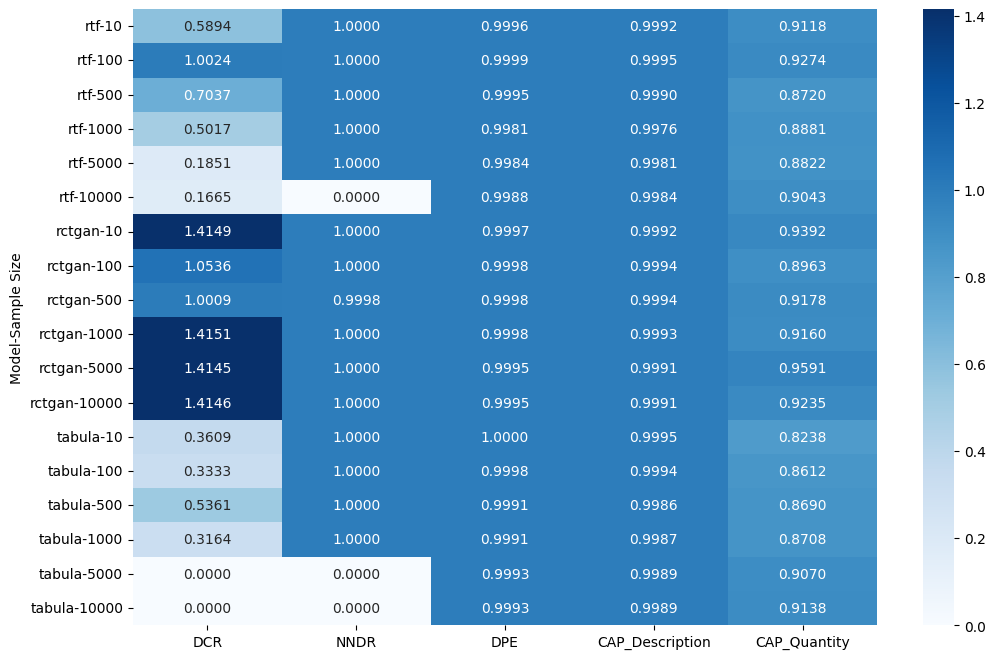

In [ ]:
heatmap_data = results_df.select_dtypes(include=[np.number])
plt.figure(figsize=(12, 8))
sns.heatmap(heatmap_data, cmap='Blues', annot=True, fmt=".4f")
plt.show()


In [ ]:
# results_df.to_csv("../results/summary.csv")

In [2]:
# dcr_results = {}

# real_vec = dfs_transformed['Test']
# for size in sample_sizes:
#     syn_vec = dfs_transformed[f"train{size}"]
#     print(f"\n[train{size}]")
#     dcr_results[size] = dcr(real_vec, syn_vec)

# nndr_results = {}
# real_vec = dfs_transformed['Test']
# for size in sample_sizes:
#     syn_vec = dfs_transformed[f"train{size}"]
#     print(f"\n[train{size}]")
#     nndr_results[size] = nndr(real_vec, syn_vec)

# cap_results = {}
# for size in sample_sizes:
#     syn = dfs[f"train{size}"]
#     print(f"\n[train{size}]")
#     cap_results[size] = evaluate_categorical_cap(real_table=real, dfs=dfs)

# dpe_results = {}
# for size in sample_sizes:
#     syn = dfs[f"train{size}"]
#     print(f"\n[train{size}]")
#     dpe_results[size] = DisclosureProtectionEstimate.compute(
#         real_data=real,
#         synthetic_data=syn,
#         known_column_names=['Country'],
#         sensitive_column_names=['Description'],
#         num_rows_subsample=2500,
#         num_iterations=100,
#         verbose=True
#     )


In [35]:
dd = pd.read_csv("../results/summary.csv")
dd['DCR'][0]

'[0.62546765 0.55331602 0.09186296 ... 0.7691792  0.2799699  1.41421356]'